## Logistic Regression Implementation 

In [1]:
# import liberaries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification
x,y =make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=42)

In [3]:
pd.DataFrame(x)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [4]:
#Train_Test_Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [5]:
#model_traning
from sklearn.linear_model import LogisticRegression
Logistic = LogisticRegression()
Logistic.fit(x_train,y_train)
y_pred = Logistic.predict(x_test)

In [6]:
Logistic.predict_proba(x_test)

array([[7.80402833e-01, 2.19597167e-01],
       [3.33949444e-02, 9.66605056e-01],
       [6.54296825e-01, 3.45703175e-01],
       [7.74596952e-02, 9.22540305e-01],
       [9.74932212e-01, 2.50677881e-02],
       [4.02885463e-02, 9.59711454e-01],
       [9.77941181e-01, 2.20588194e-02],
       [9.53536485e-01, 4.64635153e-02],
       [7.96205025e-01, 2.03794975e-01],
       [6.82676128e-01, 3.17323872e-01],
       [9.11092679e-01, 8.89073209e-02],
       [2.49227688e-01, 7.50772312e-01],
       [5.20867594e-01, 4.79132406e-01],
       [2.11303097e-01, 7.88696903e-01],
       [7.85887817e-01, 2.14112183e-01],
       [9.43614105e-01, 5.63858947e-02],
       [2.64777377e-02, 9.73522262e-01],
       [3.45014892e-01, 6.54985108e-01],
       [3.19886760e-01, 6.80113240e-01],
       [2.00611174e-01, 7.99388826e-01],
       [4.95911186e-01, 5.04088814e-01],
       [9.62345871e-01, 3.76541287e-02],
       [1.92455811e-01, 8.07544189e-01],
       [7.86728233e-01, 2.13271767e-01],
       [8.671754

In [7]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score = accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.84
[[ 98  15]
 [ 25 112]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       113
           1       0.88      0.82      0.85       137

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



# Hyperperemete turing and crossvelidation

In [8]:
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values= [100,10,1.0,0.1,0.01]
solvers =['newton-cg','lbfgs','liblinear','sag','saga']
Parmas = dict(penalty=penalty,C=c_values,solver=solvers)

In [9]:
from sklearn.model_selection import StratifiedKFold
Cv = StratifiedKFold()

In [10]:
#Grid Search Cv
from sklearn.model_selection import GridSearchCV
Grid = GridSearchCV(estimator = model, param_grid=Parmas,scoring='accuracy',cv=Cv,n_jobs=-1)
Grid.fit(x_train,y_train)


d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
200 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\test\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [11]:
Grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}

# Randomized Search CV

In [12]:
from sklearn.model_selection import RandomizedSearchCV
models = LogisticRegression()

penalty = ['l1', 'l2', 'elasticnet']
c_values= [100,10,1.0,0.1,0.01]
solvers =['newton-cg','lbfgs','liblinear','sag','saga']
Parmas = dict(penalty=penalty,C=c_values,solver=solvers)

Randomcv = RandomizedSearchCV(estimator= models,param_distributions=Parmas ,cv= 5 ,scoring='accuracy')

In [13]:
Randomcv.fit(x_train,y_train)

d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\test\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, sel

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [100, 10, 1.0, 0.1, 0.01],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   scoring='accuracy')

In [14]:
Y_pred = Randomcv.predict(x_test)

In [15]:
print('accuracy_score:', accuracy_score(Y_pred,y_test))
print('confusion_matrix:', confusion_matrix(Y_pred,y_test))
print('classification_report:', classification_report(Y_pred,y_test))

accuracy_score: 0.848
confusion_matrix: [[101  26]
 [ 12 111]]
classification_report:               precision    recall  f1-score   support

           0       0.89      0.80      0.84       127
           1       0.81      0.90      0.85       123

    accuracy                           0.85       250
   macro avg       0.85      0.85      0.85       250
weighted avg       0.85      0.85      0.85       250



In [16]:
Randomcv.best_estimator_

LogisticRegression(C=0.1, solver='liblinear')

In [17]:
Randomcv.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'C': 0.1}

In [18]:
X,Y =make_classification(n_samples=1000,n_features=10,n_informative=3,n_classes=3,random_state=42)

In [19]:
from sklearn.model_selection import train_test_split
x_train2,x_test2,y_train2,y_test2 = train_test_split(X,Y,test_size=0.30,random_state=42)


In [20]:
Logicst = LogisticRegression(multi_class='ovr')

In [21]:
Logicst.fit(x_test2,y_test2)

d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [22]:
y_pred2 = Logicst.predict(x_test2)

In [23]:
print(accuracy_score(y_pred2,y_test2))
print(classification_report(y_pred2,y_test2))
print(confusion_matrix(y_pred2,y_test2))

0.69
              precision    recall  f1-score   support

           0       0.84      0.67      0.75       130
           1       0.35      0.63      0.45        54
           2       0.85      0.74      0.79       116

    accuracy                           0.69       300
   macro avg       0.68      0.68      0.66       300
weighted avg       0.76      0.69      0.71       300

[[87 40  3]
 [ 8 34 12]
 [ 8 22 86]]


In [28]:
from collections import Counter
from sklearn.datasets import make_classification
x,y= make_classification(n_samples=10000,n_clusters_per_class=1,
n_redundant=0,weights=[0.99],random_state=10)

In [29]:
x

array([[ 0.9788705 , -0.25344851, -1.30623097, ...,  1.96819248,
         2.22881128, -0.06736091],
       [ 0.20276926,  0.48473095,  0.94415911, ..., -0.07820068,
         1.03776926, -0.37873389],
       [ 0.24778224, -1.09491297,  0.70979654, ..., -0.29971195,
        -0.16943521,  0.37234719],
       ...,
       [-1.33701471,  0.26011326,  0.10119747, ..., -0.4147124 ,
        -0.53351491,  0.85181505],
       [ 0.7168617 ,  1.26459534,  0.69784612, ..., -0.40314213,
        -0.8587251 ,  0.30025887],
       [-2.42065092, -0.47616121, -1.68623807, ..., -1.15282293,
         0.63882171,  1.38918583]])

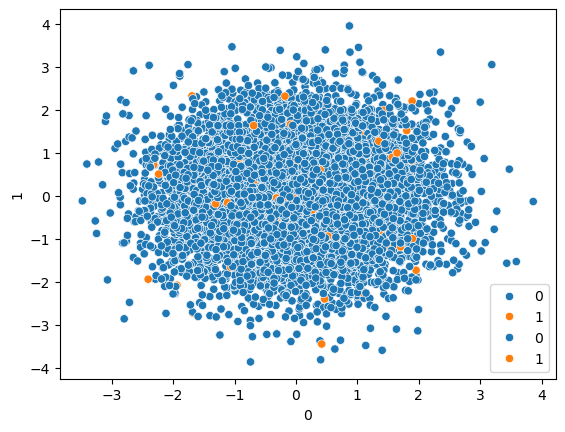

In [34]:
df = pd.DataFrame(x)
sns.scatterplot(x=df[0], y=df[1], hue=y)
plt.show();

In [35]:
x_train,x_test,y_train,y_test,=train_test_split(x,y,test_size=0.25,random_state=42)

In [37]:
#hyper parametrs turing
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values= [100,10,1.0,0.1,0.01]
solvers =['newton-cg','lbfgs','liblinear','sag','saga']
class_weights =[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
Parmas = dict(penalty=penalty,C=c_values,solver=solvers,class_weight=class_weights)

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import  StratifiedKFold

In [39]:
CV =StratifiedKFold()

In [43]:
GRID = GridSearchCV(estimator=model,param_grid=Parmas,scoring ='accuracy',cv=CV)

In [44]:
GRID.fit(x_train,y_train)

d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [47]:
y_pred3 = GRID.predict(x_test)

In [48]:
print(accuracy_score(y_pred3,y_test))
print(classification_report(y_pred3,y_test))
print(confusion_matrix(y_pred3,y_test))

0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2495
           1       0.17      1.00      0.29         5

    accuracy                           0.99      2500
   macro avg       0.58      0.99      0.64      2500
weighted avg       1.00      0.99      0.99      2500

[[2470   25]
 [   0    5]]
